<a href="https://colab.research.google.com/github/Innovatewithapple/SKLearnRegressionProblems/blob/main/RegressionInsurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
from google.colab import files,userdata

In [3]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

print('kaggle api activated via secrets')

kaggle api activated via secrets


In [4]:
!kaggle datasets download -d mosapabdelghany/medical-insurance-cost-dataset

Dataset URL: https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset
License(s): CC0-1.0
100% 16.0k/16.0k [00:00<00:00, 26.5MB/s]



In [5]:
!unzip -q /content/medical-insurance-cost-dataset.zip -d /content/

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_validate,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [7]:
df = pd.read_csv('/content/insurance.csv')
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
981,34,male,21.375,0,no,northeast,4500.33925
1044,55,male,35.245,1,no,northeast,11394.06555
1064,29,female,25.600,4,no,southwest,5708.86700
1276,22,female,30.400,0,no,northeast,2741.94800
866,18,male,37.290,0,no,southeast,1141.44510


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [12]:
df.corr()['charges']

ValueError: could not convert string to float: 'female'

Text(0.5, 1.0, 'Age vs Insurance Charges')

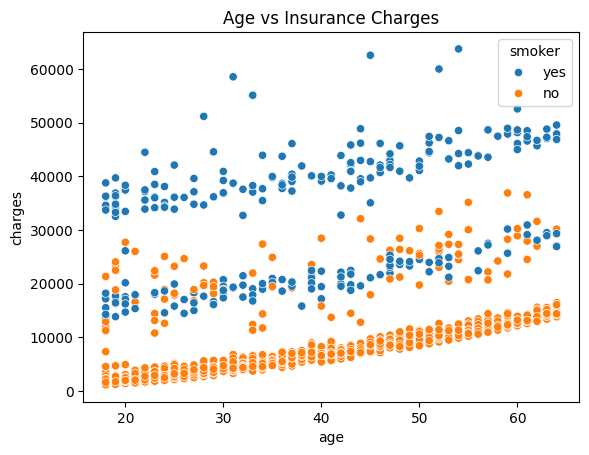

In [13]:
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title("Age vs Insurance Charges")

In [15]:
x = df.drop(columns='charges')
y = df['charges']

In [22]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [16]:
num_cols = x.select_dtypes(include=['int64','float64']).columns
cat_cols = x.select_dtypes(include='object').columns

In [17]:
num_cols

Index(['age', 'bmi', 'children'], dtype='object')

In [18]:
preprocessor = ColumnTransformer([
    ('nums',StandardScaler(),num_cols),
    ('cats',OneHotEncoder(),cat_cols)
])

In [20]:
linear_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])

In [23]:
linear_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cats', OneHotEncoder(),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('model', LinearRegression())])

In [25]:
linear_crossval = cross_validate(linear_pipeline,x_train,y_train,cv=5,scoring='r2')
linear_crossval

{'fit_time': array([0.01582861, 0.01408195, 0.01103616, 0.01167178, 0.00942111]),
 'score_time': array([0.01000476, 0.00823975, 0.00639915, 0.00625706, 0.005445  ]),
 'test_score': array([0.76276797, 0.80048429, 0.63171109, 0.68603936, 0.75806544])}

In [27]:
# Focus only on the 'test_score' array inside the dictionary
print(f"R2 Mean: {linear_crossval['test_score'].mean()}")
print(f"R2 Std Dev: {linear_crossval['test_score'].std()}")

R2 Mean: 0.7278136313857186
R2 Std Dev: 0.06066101013562642


Text(0.5, 1.0, "Actual vs Predicted: The 'Iron Rod' Struggle")

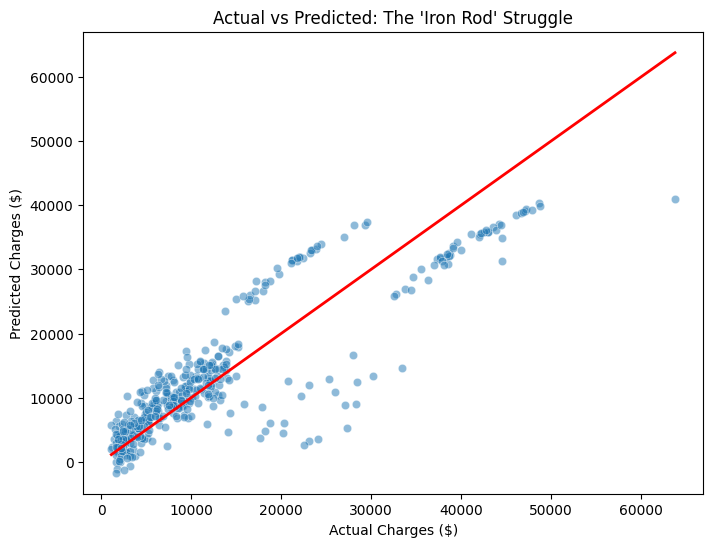

In [28]:
# Make predictions on your test set
y_pred = linear_pipeline.predict(x_test)

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
# Draw the 'Perfect Prediction' line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title("Actual vs Predicted: The 'Iron Rod' Struggle")

Text(0.5, 1.0, 'How the Line tries to follow Age')

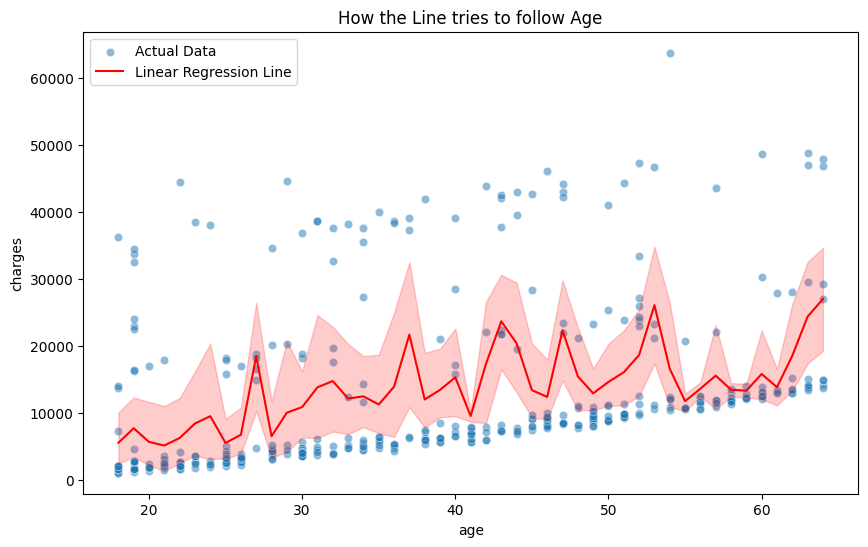

In [29]:
plt.figure(figsize=(10,6))
# 1. Plot the real dots (Actual)
sns.scatterplot(x=x_test['age'], y=y_test, alpha=0.5, label='Actual Data')
# 2. Plot your model's guesses (The Line)
sns.lineplot(x=x_test['age'], y=y_pred, color='red', label='Linear Regression Line')
plt.title("How the Line tries to follow Age")

Lasso (L1) and Ridge(L2)

In [34]:
Ridge_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',Ridge())
])

Lasso_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',Lasso())
])

In [35]:
Ridge_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cats', OneHotEncoder(),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('model', Ridge())])

In [36]:
Lasso_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cats', OneHotEncoder(),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('model', Lasso())])

In [37]:
param_grid = {
    'model__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]
}

# 3. The Search
# We use 'neg_mean_absolute_error' to see the "Dollar Error"
grid_ridge = GridSearchCV(
    Ridge_pipeline,
    param_grid,
    cv=5,
    scoring='r2' # Let's stick to R2 first to compare with your 0.75 baseline
)

grid_ridge.fit(x_train, y_train)

print(f"Best Alpha: {grid_ridge.best_params_}")
print(f"Best R2 Score: {grid_ridge.best_score_}")

Best Alpha: {'model__alpha': 1.0}
Best R2 Score: 0.7278896681043466


In [40]:
param_grid = {
    'model__alpha': [0.001,0.01,0.1, 1.0, 10.0]
}

# 3. The Search
# We use 'neg_mean_absolute_error' to see the "Dollar Error"
grid_Lasso = GridSearchCV(
    Lasso_pipeline,
    param_grid,
    cv=5,
    scoring='r2' # Let's stick to R2 first to compare with your 0.75 baseline
)

grid_Lasso.fit(x_train, y_train)

print(f"Best Alpha: {grid_Lasso.best_params_}")
print(f"Best R2 Score: {grid_Lasso.best_score_}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.107e+08, tolerance: 1.088e+07
  model = cd_fast.enet_coordinate_descent(


Best Alpha: {'model__alpha': 10.0}
Best R2 Score: 0.7280207099432561


SVM Pipeline

In [50]:
svr_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',SVR(kernel='rbf'))
])

In [51]:
svr_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cats', OneHotEncoder(),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('model', SVR())])

In [52]:
svr_crossscore = cross_validate(svr_pipeline,x_train,y_train,cv=5,scoring='r2')

In [53]:
print(f"SVR Baseline R2 Mean: {svr_crossscore['test_score'].mean()}")
print(f"SVR Baseline R2 Std Dev: {svr_crossscore['test_score'].std()}")

SVR Baseline R2 Mean: -0.10372146259573278
SVR Baseline R2 Std Dev: 0.03504270835069609


In [54]:
param_grid = {
    # We move from tiny C to massive C
    'model__C': [1, 100, 1000, 10000, 50000],
    'model__epsilon': [0.1, 1, 10, 100, 1000],
    'model__kernel': ['rbf']
}

grid_svr = GridSearchCV(svr_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_svr.fit(x_train, y_train)

print(f"Best Params: {grid_svr.best_params_}")
print(f"Best Score: {grid_svr.best_score_}")

Best Params: {'model__C': 10000, 'model__epsilon': 1000, 'model__kernel': 'rbf'}
Best Score: 0.8212335591173046


Final R2 Score: 0.854672124891847
Final MAE: $2251.75


Text(0.5, 1.0, "SVR: Did the 'Tube' catch the dots?")

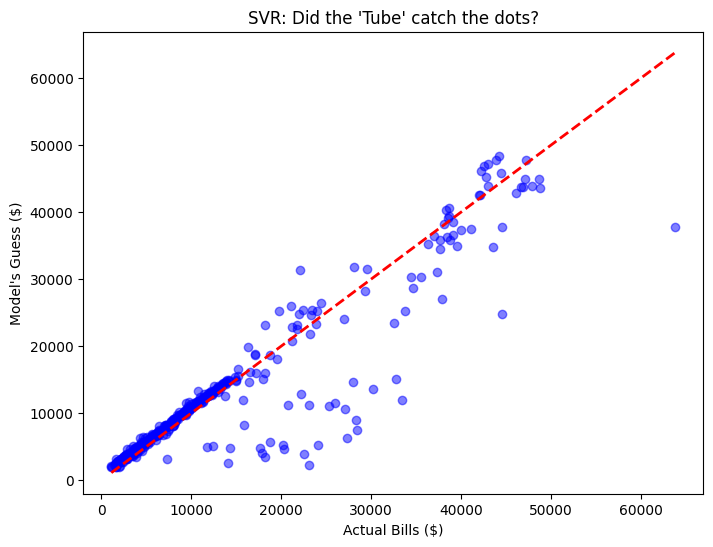

In [56]:
# 1. Predict using the best version of the model
y_pred = grid_svr.best_estimator_.predict(x_test)

# 2. Check the Final Scores
print(f"Final R2 Score: {r2_score(y_test, y_pred)}")
print(f"Final MAE: ${mean_absolute_error(y_test, y_pred):.2f}")

# 3. Visualize the "Bending Line" Success
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Bills ($)")
plt.ylabel("Model's Guess ($)")
plt.title("SVR: Did the 'Tube' catch the dots?")

Random Forest Regressor

In [58]:
randomForest_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor())
])

In [59]:
randomForest_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cats', OneHotEncoder(),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('model', RandomForestRegressor())])

In [62]:
randomForest_cross_score = cross_validate(randomForest_pipeline,x_train,y_train,cv=5,scoring='r2')
print('R2 Mean: ',randomForest_cross_score['test_score'].mean())
print('R2 STD: ',randomForest_cross_score['test_score'].std())

R2 Mean:  0.8173887672836437
R2 STD:  0.039585172804858966


In [63]:
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 15, None],
    'model__min_samples_split': [2, 5, 10], # <--- Control the "starting" of a split
    'model__min_samples_leaf': [1, 2, 4],   # <--- Control the "size" of the final group
    'model__max_features': ['sqrt', None]
}

In [68]:
randomforest_Grid = GridSearchCV(randomForest_pipeline,rf_param_grid,cv=2,verbose=2,scoring='r2')
randomforest_Grid.fit(x_train,y_train)

Fitting 2 folds for each of 108 candidates, totalling 216 fits
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time=   0.3s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time=   0.3s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=   0.1s
[CV] EN

GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('nums',
                                                                         StandardScaler(),
                                                                         Index(['age', 'bmi', 'children'], dtype='object')),
                                                                        ('cats',
                                                                         OneHotEncoder(),
                                                                         Index(['sex', 'smoker', 'region'], dtype='object'))])),
                                       ('model', RandomForestRegressor())]),
             param_grid={'model__max_depth': [10, 15, None],
                         'model__max_features': ['sqrt', None],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200]},
             scoring='r2', verbose=2)

In [69]:
print(randomforest_Grid.best_params_)

{'model__max_depth': None, 'model__max_features': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 200}


In [70]:
y_pred_forest = randomforest_Grid.best_estimator_.predict(x_test)

# 2. Check the Final Scores
print(f"Final R2 Score: {r2_score(y_test, y_pred_forest)}")
print(f"Final MAE: ${mean_absolute_error(y_test, y_pred_forest):.2f}")

Final R2 Score: 0.8696703612784769
Final MAE: $2448.00


Text(0.5, 1.0, 'The Real Drivers of Medical Costs')

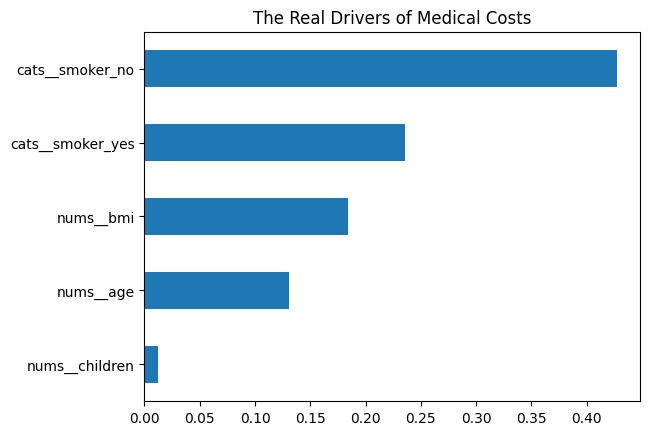

In [72]:
# Extract the importance from the winning forest
importances = randomforest_Grid.best_estimator_.named_steps['model'].feature_importances_
feature_names = randomforest_Grid.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

# Create a Series and plot the top 5
pd.Series(importances, index=feature_names).sort_values().tail(5).plot(kind='barh')
plt.title("The Real Drivers of Medical Costs")